Seleção de colunas e PCA

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df = pd.read_csv("./raw/dataset_merged.csv", parse_dates=["date"])

cols = ["date", "credit_spread", "industrial_production", "price_index",
        "real_interest", "volatility_index", "yield_curve_slope", "target_12m"]

df = df[cols].dropna().reset_index(drop=True)

features = ["credit_spread", "industrial_production", "price_index",
            "real_interest", "volatility_index", "yield_curve_slope"]

X = df[features].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["pca_1", "pca_2","pca_3"])
df_pca = pd.concat(
    [df_pca, df[["date", "target_12m"]].reset_index(drop=True)],
    axis=1
)

variancia_explicada = pca.explained_variance_ratio_
variacia_total = variancia_explicada.sum()

print(f"Variancia explicada pela PC1: {variancia_explicada[0]:.2%}")
print(f"Variancia explicada pela PC2: {variancia_explicada[1]:.2%}")
print(f"Variancia explicada pela PC3: {variancia_explicada[2]:.2%}")

print(f"Variância total explicada pelos quatro componentes: {variacia_total:.2%}")

Variancia explicada pela PC1: 44.70%
Variancia explicada pela PC2: 30.59%
Variancia explicada pela PC3: 15.77%
Variância total explicada pelos quatro componentes: 91.06%


Divisão entre treino e teste

In [15]:
from sklearn.model_selection import train_test_split

df = df.sort_values("date").reset_index(drop=True)
df_pca = df_pca.sort_values("date").reset_index(drop=True)

X_no_pca = df[features]
X_pca_features = df_pca[["pca_1", "pca_2", "pca_3"]]
y = df["target_12m"]

X_train_no_pca, X_test_no_pca, y_train_no_pca, y_test_no_pca = train_test_split(
    X_no_pca,
    y,
    test_size=0.3,
    shuffle=True,
    random_state=42,
    stratify=y
)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_features,
    y,
    test_size=0.3,
    shuffle=True,
    random_state=42,
    stratify=y
)

O motivo da utilização do shuffle=True com stratify=y se dá por um problema encontrado na distribuição dos dados: a classe 3, que representa crise inflacionária/monetária, ocorreu exclusivamente entre março de 2021 e abril de 2023, fazendo com que, em um split cronológico, essa classe aparecesse apenas no conjunto de teste. Para resolver isso, foi utilizado o embaralhamento, garantindo que as 4 classes estejam presentes tanto no treino quanto no teste. Porém, é importante ressaltar que com essa abordagem o modelo pode visualizar dados futuros durante o treinamento, o que pode inflar as métricas de desempenho e deve ser considerado na interpretação dos resultados.

Função base de treino, teste e plot dos modelos

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import pandas as pd

LABELS = ["Normal", "Recessão", "Crise Financeira", "Crise Inflacionária/Monetária"]

resultados = []

def avaliar_modelo(model, X_train, X_test, y_train, y_test, nome_modelo="Modelo"):

    print(f"\n===== {nome_modelo} =====")

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("\n--- TREINO ---")
    print(classification_report(y_train, y_pred_train, target_names=LABELS))

    print("\n--- TESTE ---")
    print(classification_report(y_test, y_pred_test, target_names=LABELS))

    # ===== ACUMULA RESULTADOS =====
    resultados.append({
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test, average="macro", zero_division=0),
        "recall": recall_score(y_test, y_pred_test, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred_test, average="macro", zero_division=0),
    })

    # ===== MATRIZ TREINO =====
    cm_train = confusion_matrix(y_train, y_pred_train)
    disp_train = ConfusionMatrixDisplay(cm_train, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp_train.plot(ax=ax, xticks_rotation=45)
    ax.set_title(f"{nome_modelo} - Matriz de Confusão (Treino)")
    plt.tight_layout()
    plt.show()

    # ===== MATRIZ TESTE =====
    cm_test = confusion_matrix(y_test, y_pred_test)
    disp_test = ConfusionMatrixDisplay(cm_test, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp_test.plot(ax=ax, xticks_rotation=45)
    ax.set_title(f"{nome_modelo} - Matriz de Confusão (Teste)")
    plt.tight_layout()
    plt.show()

Árvore de Decisão

Melhores parâmetros (sem PCA):
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

===== Decision Tree (sem PCA) =====

--- TREINO ---
                               precision    recall  f1-score   support

                       Normal       1.00      1.00      1.00       166
                     Recessão       1.00      1.00      1.00        19
             Crise Financeira       1.00      1.00      1.00       101
Crise Inflacionária/Monetária       1.00      1.00      1.00        18

                     accuracy                           1.00       304
                    macro avg       1.00      1.00      1.00       304
                 weighted avg       1.00      1.00      1.00       304


--- TESTE ---
                               precision    recall  f1-score   support

                       Normal       0.96      0.96      0.96        72
                     Recessão       1.00      1.00      1.00         8
             Crise Financeira       0.95      0.9

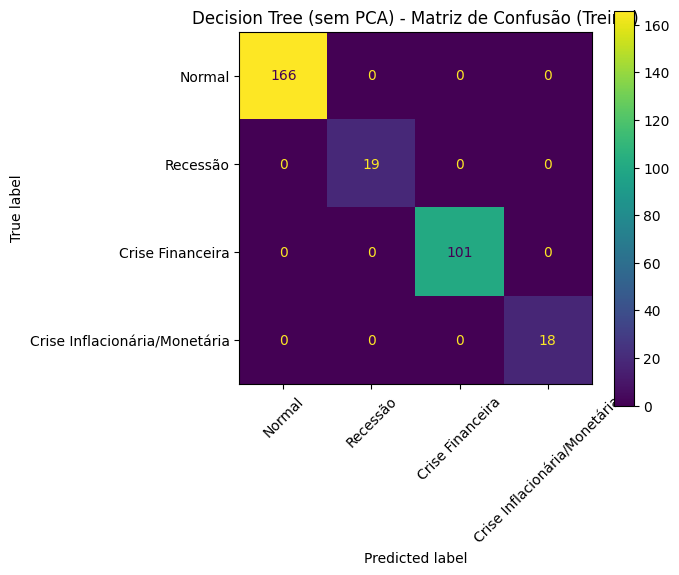

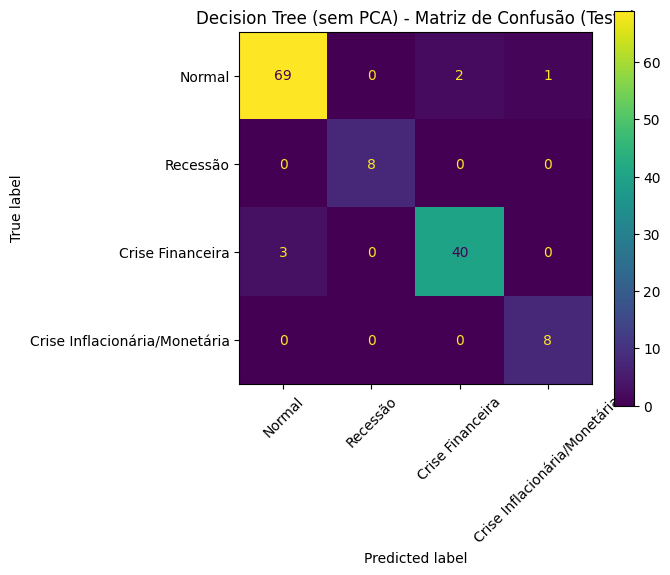

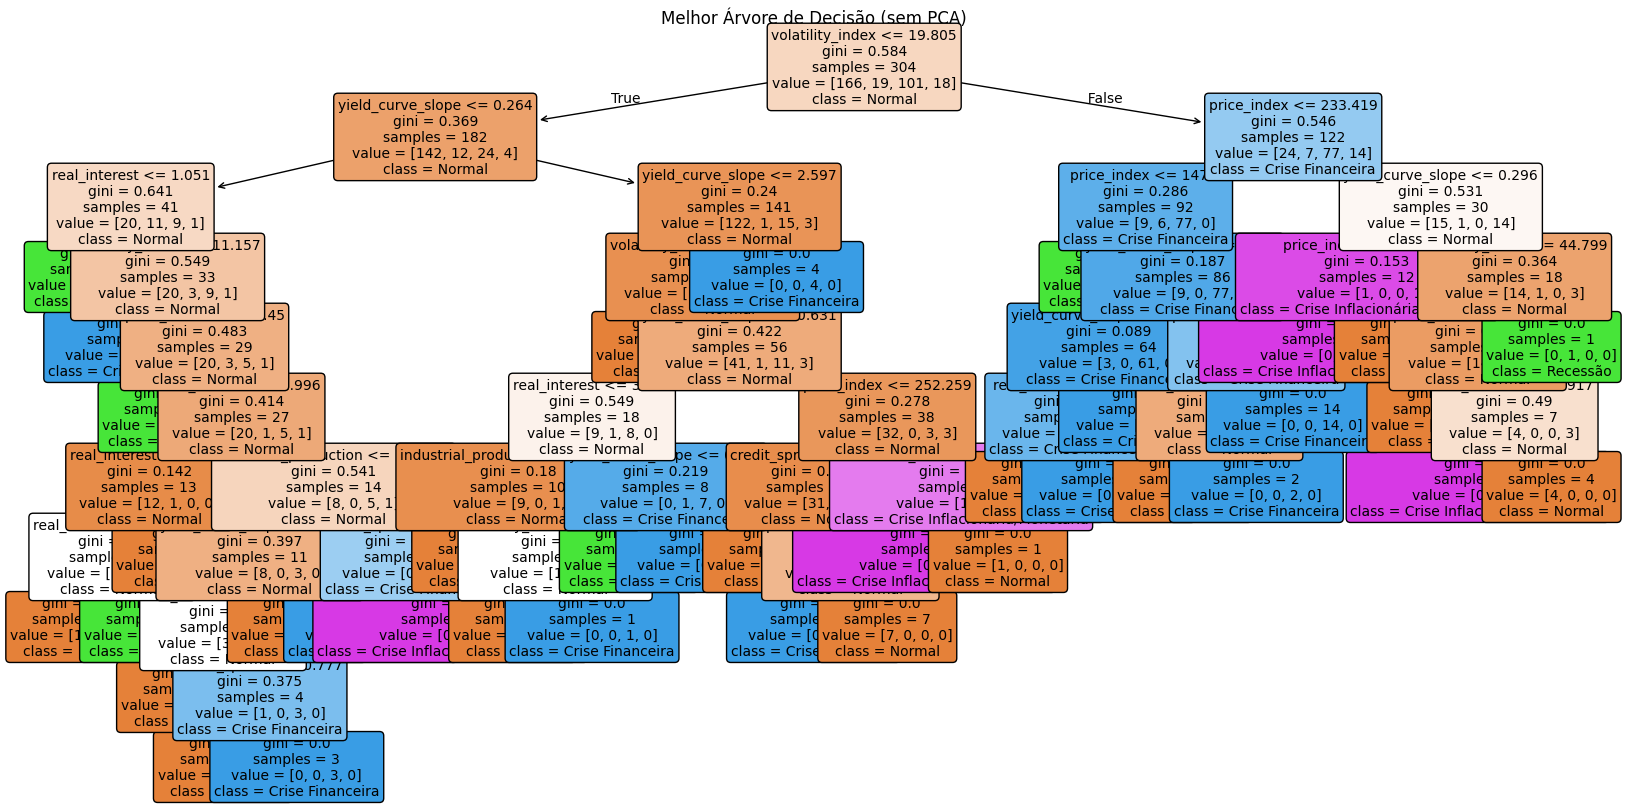

Melhores parâmetros (PCA):
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

===== Decision Tree (PCA) =====

--- TREINO ---
                               precision    recall  f1-score   support

                       Normal       1.00      1.00      1.00       166
                     Recessão       1.00      1.00      1.00        19
             Crise Financeira       1.00      1.00      1.00       101
Crise Inflacionária/Monetária       1.00      1.00      1.00        18

                     accuracy                           1.00       304
                    macro avg       1.00      1.00      1.00       304
                 weighted avg       1.00      1.00      1.00       304


--- TESTE ---
                               precision    recall  f1-score   support

                       Normal       0.78      0.82      0.80        72
                     Recessão       0.44      0.50      0.47         8
             Crise Financeira       0.74      0.67      0

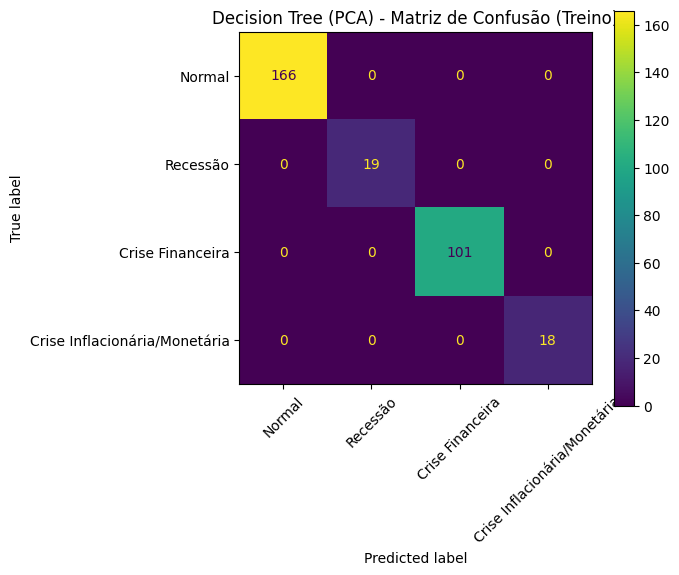

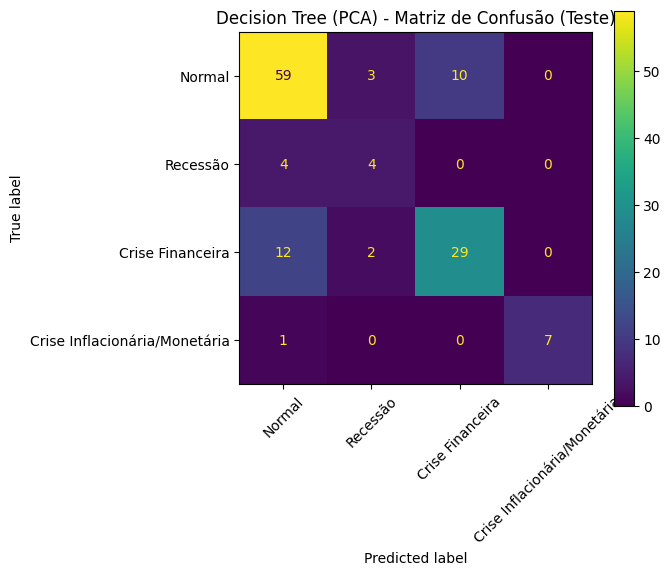

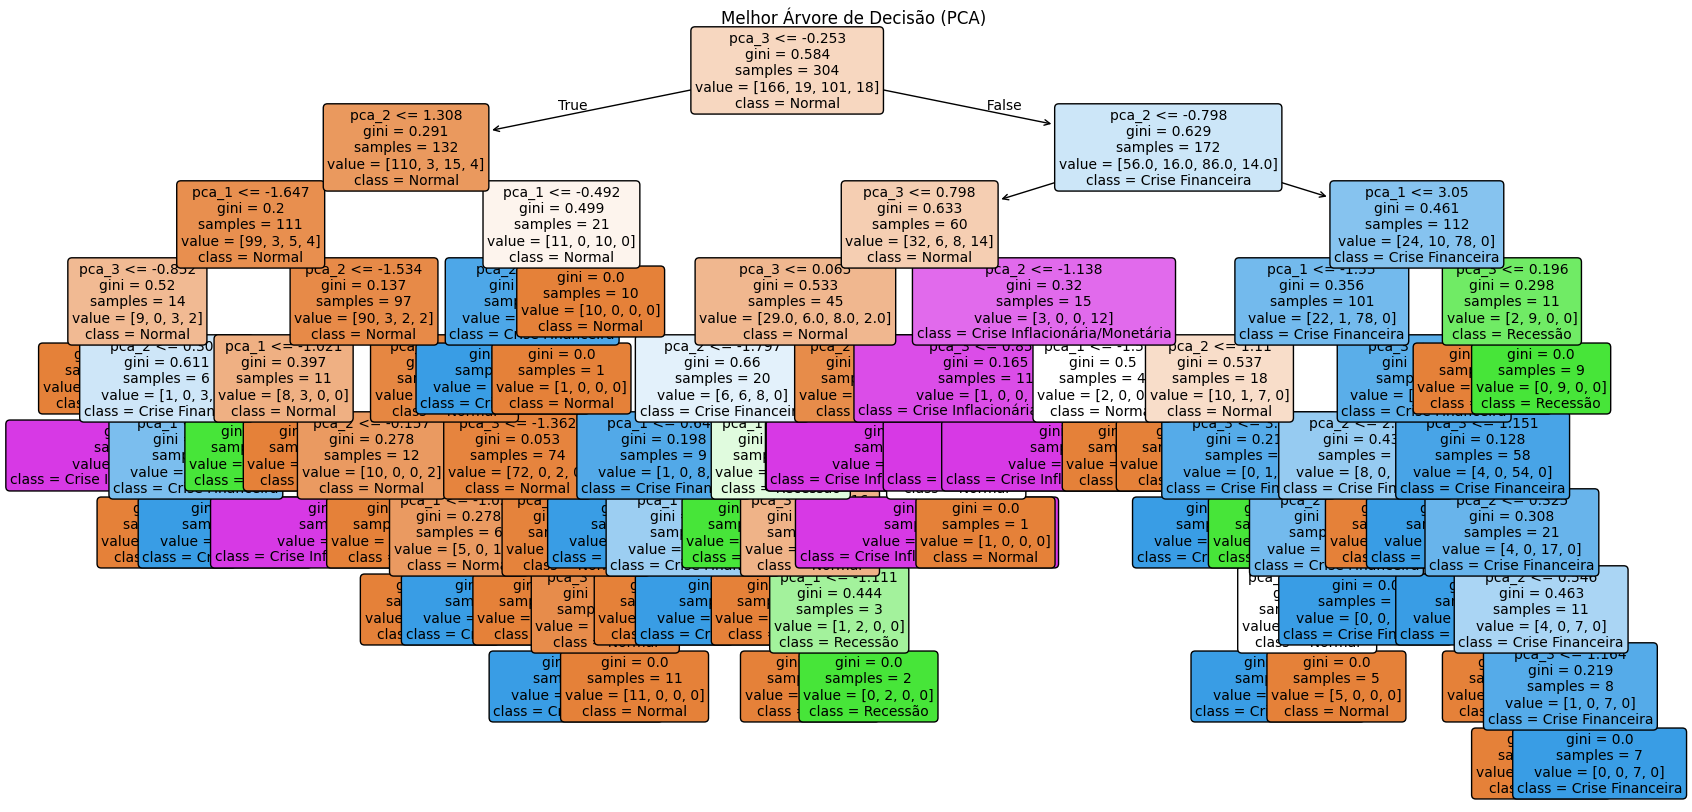

In [17]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# ===== GRID DE HIPERPARÂMETROS =====
param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# ===== MODELO BASE =====
tree = DecisionTreeClassifier(random_state=42)

# ===== TREINAR SEM PCA =====
grid_no_pca = GridSearchCV(
    tree,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

best_tree_no_pca = grid_no_pca.best_estimator_

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_tree_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Decision Tree (sem PCA)"
)

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree_no_pca,
    feature_names=features,
    class_names=LABELS,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Melhor Árvore de Decisão (sem PCA)")
plt.show()

# ===== TREINAR COM PCA =====
grid_pca = GridSearchCV(
    tree,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_pca.fit(X_train_pca, y_train_pca)

best_tree_pca = grid_pca.best_estimator_

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_tree_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Decision Tree (PCA)"
)

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree_pca,
    feature_names=["pca_1", "pca_2", "pca_3"],
    class_names=LABELS,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Melhor Árvore de Decisão (PCA)")
plt.show()

KNN

Melhores parâmetros (sem PCA):
{'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}

===== KNN (sem PCA) =====

--- TREINO ---
                               precision    recall  f1-score   support

                       Normal       1.00      1.00      1.00       166
                     Recessão       1.00      1.00      1.00        19
             Crise Financeira       1.00      1.00      1.00       101
Crise Inflacionária/Monetária       1.00      1.00      1.00        18

                     accuracy                           1.00       304
                    macro avg       1.00      1.00      1.00       304
                 weighted avg       1.00      1.00      1.00       304


--- TESTE ---
                               precision    recall  f1-score   support

                       Normal       0.96      0.94      0.95        72
                     Recessão       1.00      1.00      1.00         8
             Crise Financeira       0.95

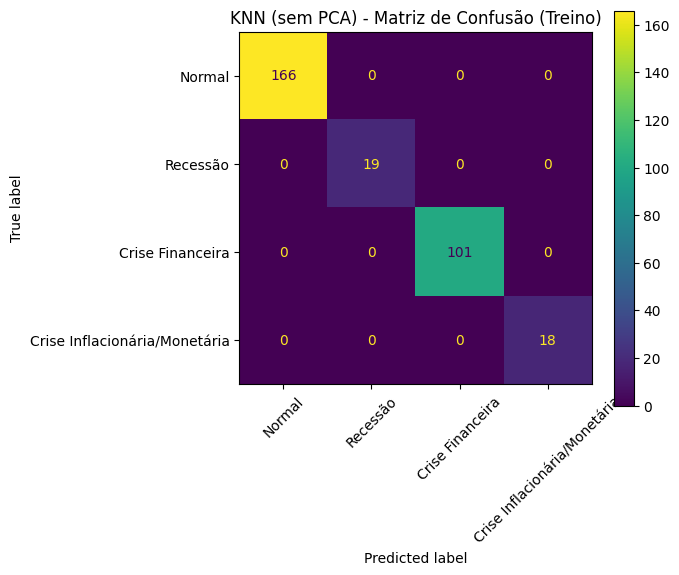

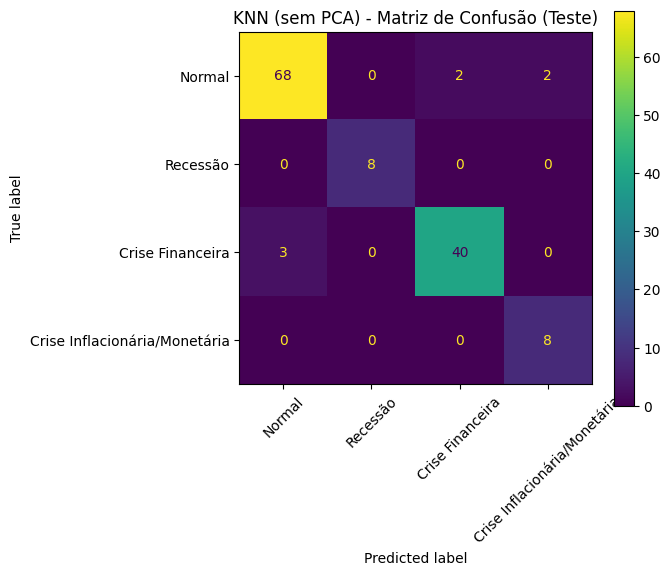

Melhores parâmetros (PCA):
{'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'distance'}

===== KNN (PCA) =====

--- TREINO ---
                               precision    recall  f1-score   support

                       Normal       1.00      1.00      1.00       166
                     Recessão       1.00      1.00      1.00        19
             Crise Financeira       1.00      1.00      1.00       101
Crise Inflacionária/Monetária       1.00      1.00      1.00        18

                     accuracy                           1.00       304
                    macro avg       1.00      1.00      1.00       304
                 weighted avg       1.00      1.00      1.00       304


--- TESTE ---
                               precision    recall  f1-score   support

                       Normal       0.93      0.94      0.94        72
                     Recessão       1.00      0.75      0.86         8
             Crise Financeira       0.93      0.

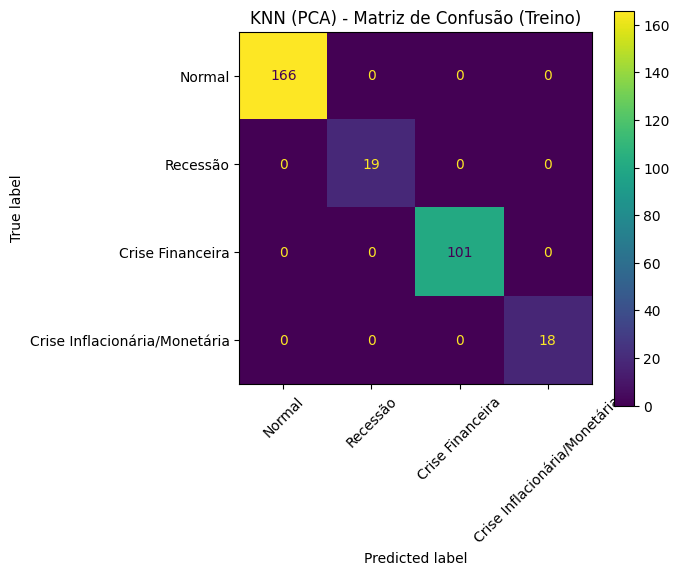

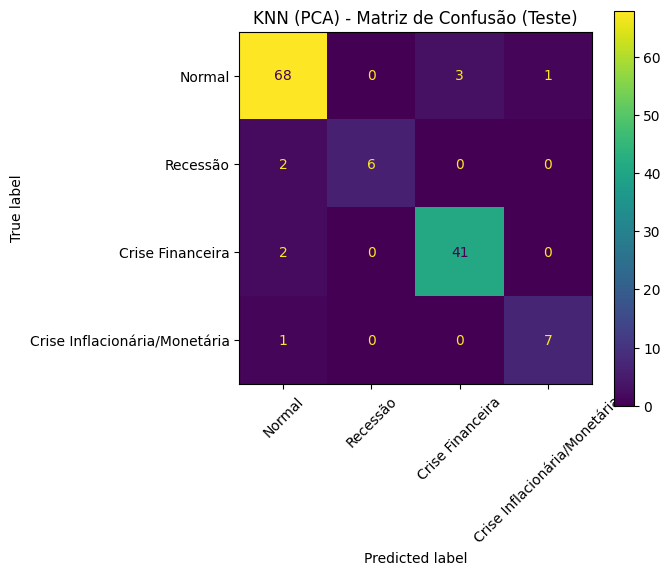

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ===== PIPELINE =====
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

# ===== GRID =====
param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

# ===== TREINAR SEM PCA =====
grid_no_pca = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

best_knn_no_pca = grid_no_pca.best_estimator_

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_knn_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="KNN (sem PCA)"
)

# ===== TREINAR COM PCA =====
grid_pca = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_pca.fit(X_train_pca, y_train_pca)

best_knn_pca = grid_pca.best_estimator_

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_knn_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="KNN (PCA)"
)

Voting Classifier


===== Voting Ensemble (sem PCA) =====

--- TREINO ---
                               precision    recall  f1-score   support

                       Normal       0.95      0.98      0.96       166
                     Recessão       1.00      0.95      0.97        19
             Crise Financeira       0.96      0.97      0.97       101
Crise Inflacionária/Monetária       1.00      0.78      0.88        18

                     accuracy                           0.96       304
                    macro avg       0.98      0.92      0.94       304
                 weighted avg       0.96      0.96      0.96       304


--- TESTE ---
                               precision    recall  f1-score   support

                       Normal       0.93      0.96      0.95        72
                     Recessão       1.00      1.00      1.00         8
             Crise Financeira       0.95      0.93      0.94        43
Crise Inflacionária/Monetária       0.86      0.75      0.80         8

  

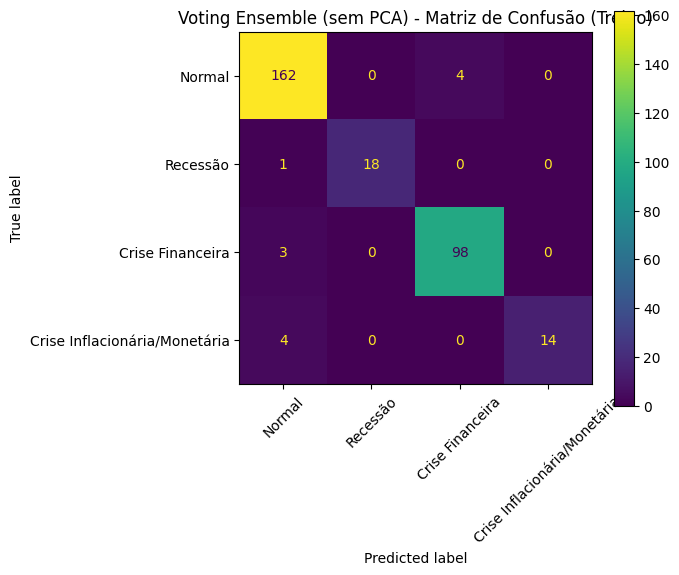

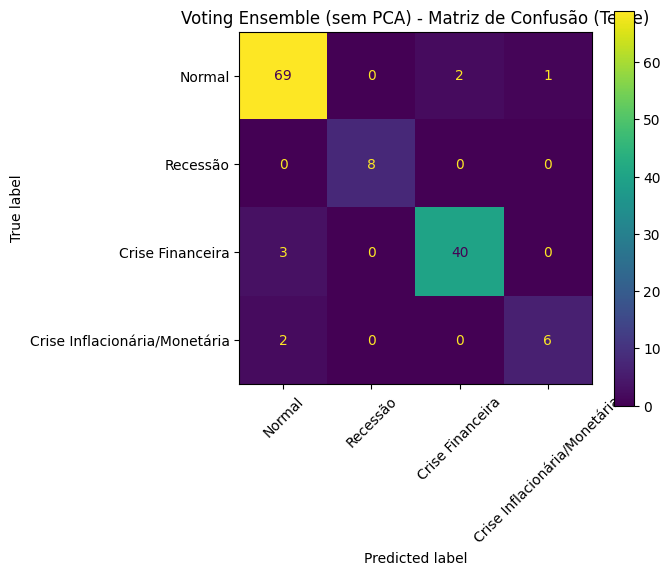


===== Voting Ensemble (PCA) =====

--- TREINO ---
                               precision    recall  f1-score   support

                       Normal       0.95      0.96      0.95       166
                     Recessão       1.00      0.84      0.91        19
             Crise Financeira       0.92      0.96      0.94       101
Crise Inflacionária/Monetária       1.00      0.89      0.94        18

                     accuracy                           0.95       304
                    macro avg       0.97      0.91      0.94       304
                 weighted avg       0.95      0.95      0.95       304


--- TESTE ---
                               precision    recall  f1-score   support

                       Normal       0.80      0.93      0.86        72
                     Recessão       1.00      0.50      0.67         8
             Crise Financeira       0.86      0.74      0.80        43
Crise Inflacionária/Monetária       1.00      0.75      0.86         8

      

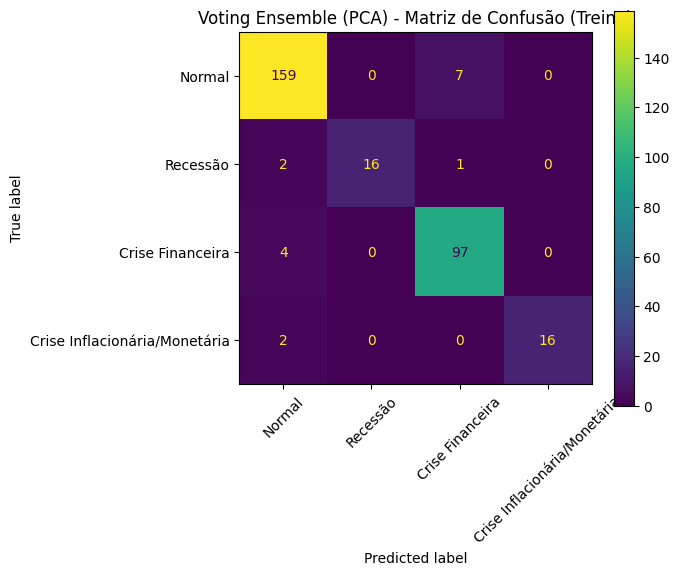

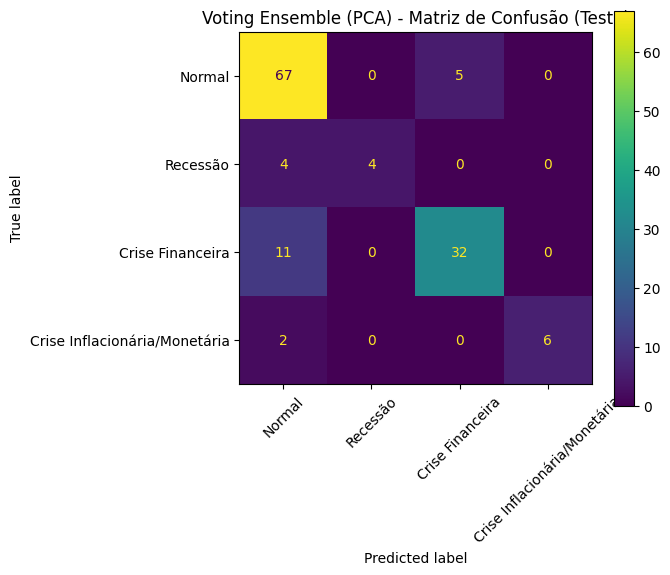

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ===== MODELOS BASE =====
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, solver="lbfgs"))
])

# ===== VOTING SEM PCA =====
voting_no_pca = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)
voting_no_pca.fit(X_train_no_pca, y_train_no_pca)

avaliar_modelo(
    voting_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Voting Ensemble (sem PCA)"
)

# ===== VOTING COM PCA =====
voting_pca = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)
voting_pca.fit(X_train_pca, y_train_pca)

avaliar_modelo(
    voting_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Voting Ensemble (PCA)"
)

Random Forest

Melhores parâmetros (sem PCA):
{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

===== Random Forest (sem PCA) =====

--- TREINO ---
                               precision    recall  f1-score   support

                       Normal       1.00      1.00      1.00       166
                     Recessão       1.00      1.00      1.00        19
             Crise Financeira       1.00      1.00      1.00       101
Crise Inflacionária/Monetária       1.00      1.00      1.00        18

                     accuracy                           1.00       304
                    macro avg       1.00      1.00      1.00       304
                 weighted avg       1.00      1.00      1.00       304


--- TESTE ---
                               precision    recall  f1-score   support

                       Normal       0.97      0.99      0.98        72
                     Recessão       1.00      0.88      0.93         8
      

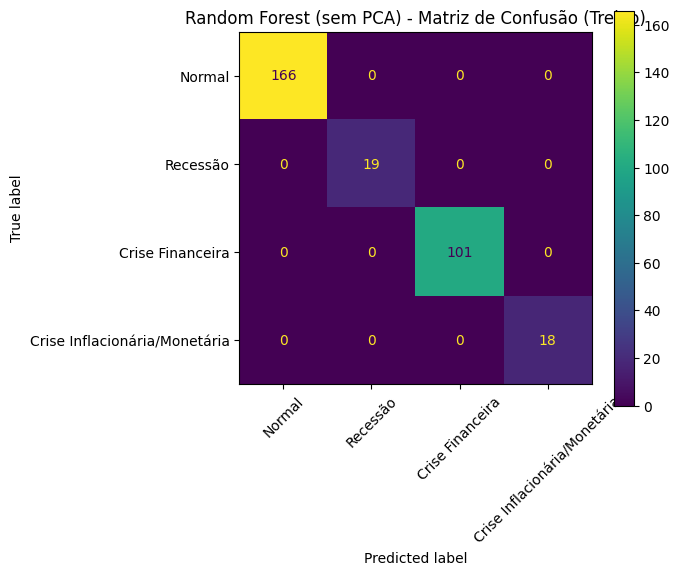

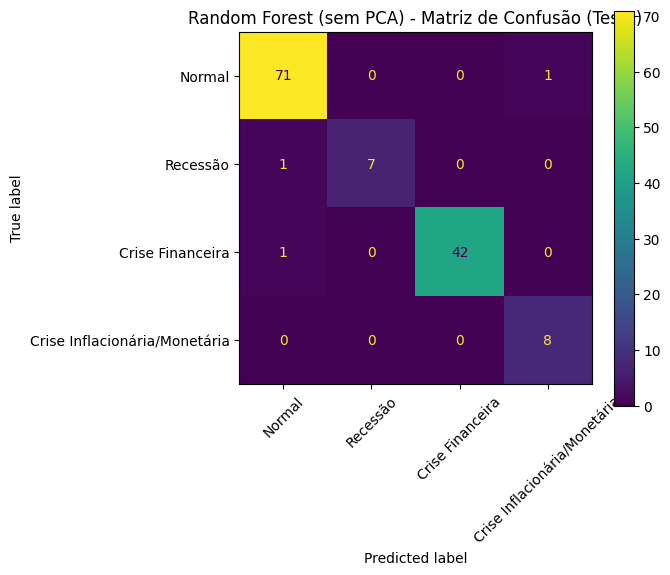


Importância das variáveis (sem PCA):
                 feature  importance
2            price_index    0.290756
4       volatility_index    0.225682
1  industrial_production    0.144396
3          real_interest    0.132626
5      yield_curve_slope    0.107808
0          credit_spread    0.098732


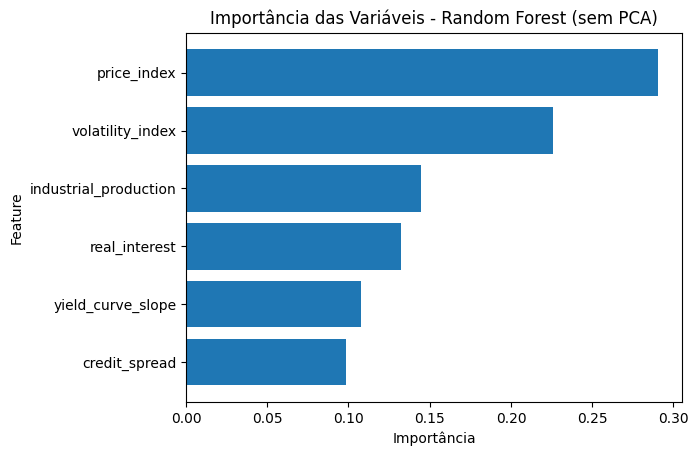

Melhores parâmetros (PCA):
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

===== Random Forest (PCA) =====

--- TREINO ---
                               precision    recall  f1-score   support

                       Normal       0.99      0.97      0.98       166
                     Recessão       1.00      1.00      1.00        19
             Crise Financeira       0.98      0.99      0.99       101
Crise Inflacionária/Monetária       0.86      1.00      0.92        18

                     accuracy                           0.98       304
                    macro avg       0.96      0.99      0.97       304
                 weighted avg       0.98      0.98      0.98       304


--- TESTE ---
                               precision    recall  f1-score   support

                       Normal       0.88      0.92      0.90        72
                     Recessão       1.00      0.75      0.86         8
          

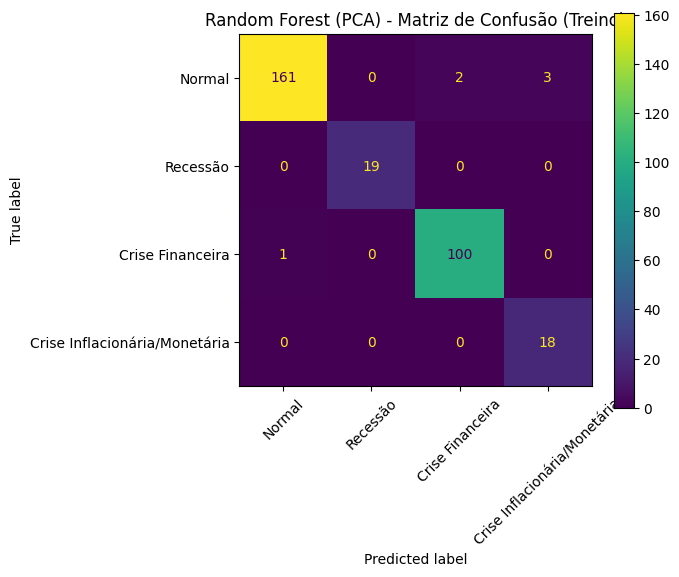

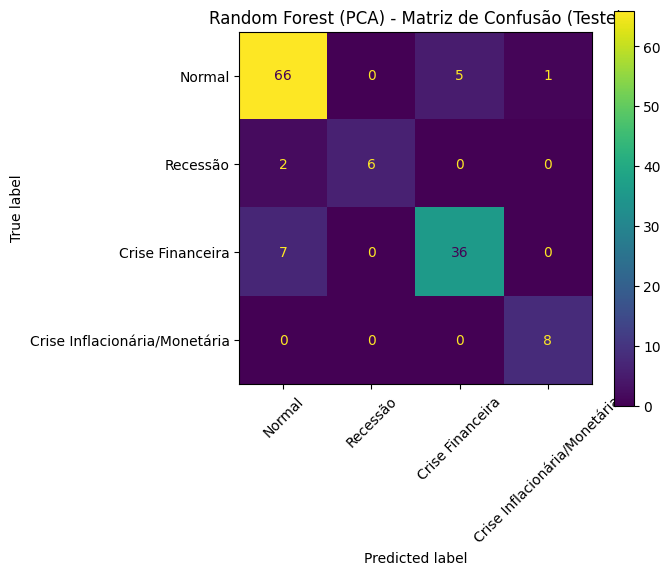


Importância das componentes PCA:
  feature  importance
0   pca_1    0.348529
2   pca_3    0.329573
1   pca_2    0.321898


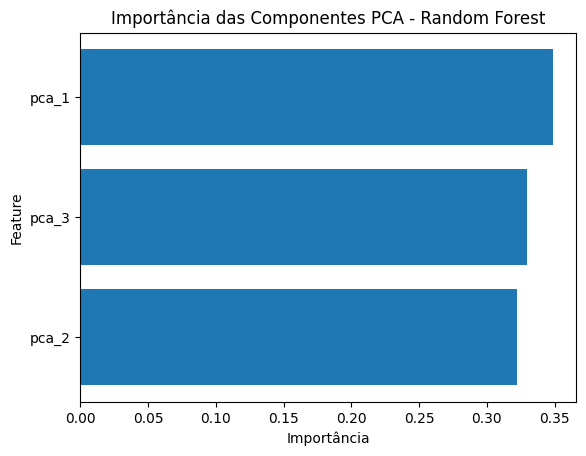

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt

# ===== GRID DE HIPERPARÂMETROS =====
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

# ===== MODELO BASE =====
rf = RandomForestClassifier(random_state=42)

# ===== TREINAR SEM PCA =====
grid_no_pca = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

best_rf_no_pca = grid_no_pca.best_estimator_

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_rf_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Random Forest (sem PCA)"
)

importances = best_rf_no_pca.feature_importances_

df_importance = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nImportância das variáveis (sem PCA):")
print(df_importance)

plt.figure()
plt.barh(df_importance["feature"], df_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis - Random Forest (sem PCA)")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

# ===== TREINAR COM PCA =====
grid_pca = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_pca.fit(X_train_pca, y_train_pca)

best_rf_pca = grid_pca.best_estimator_

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_rf_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Random Forest (PCA)"
)

importances_pca = best_rf_pca.feature_importances_

df_importance_pca = pd.DataFrame({
    "feature": ["pca_1", "pca_2", "pca_3"],
    "importance": importances_pca
}).sort_values(by="importance", ascending=False)

print("\nImportância das componentes PCA:")
print(df_importance_pca)

plt.figure()
plt.barh(df_importance_pca["feature"], df_importance_pca["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Componentes PCA - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

Comparação Final

                           accuracy  precision    recall  f1_macro
modelo                                                            
Decision Tree (sem PCA)    0.954198   0.949901  0.972141  0.960172
Decision Tree (PCA)        0.755725   0.741087  0.717216  0.727134
KNN (sem PCA)              0.946565   0.927532  0.968669  0.945279
KNN (PCA)                  0.931298   0.934581  0.880733  0.903151
Voting Ensemble (sem PCA)  0.938931   0.935489  0.909641  0.921595
Voting Ensemble (PCA)      0.832061   0.915621  0.731185  0.795696
Random Forest (sem PCA)    0.977099   0.965373  0.959464  0.960514
Random Forest (PCA)        0.885496   0.911734  0.875969  0.888355


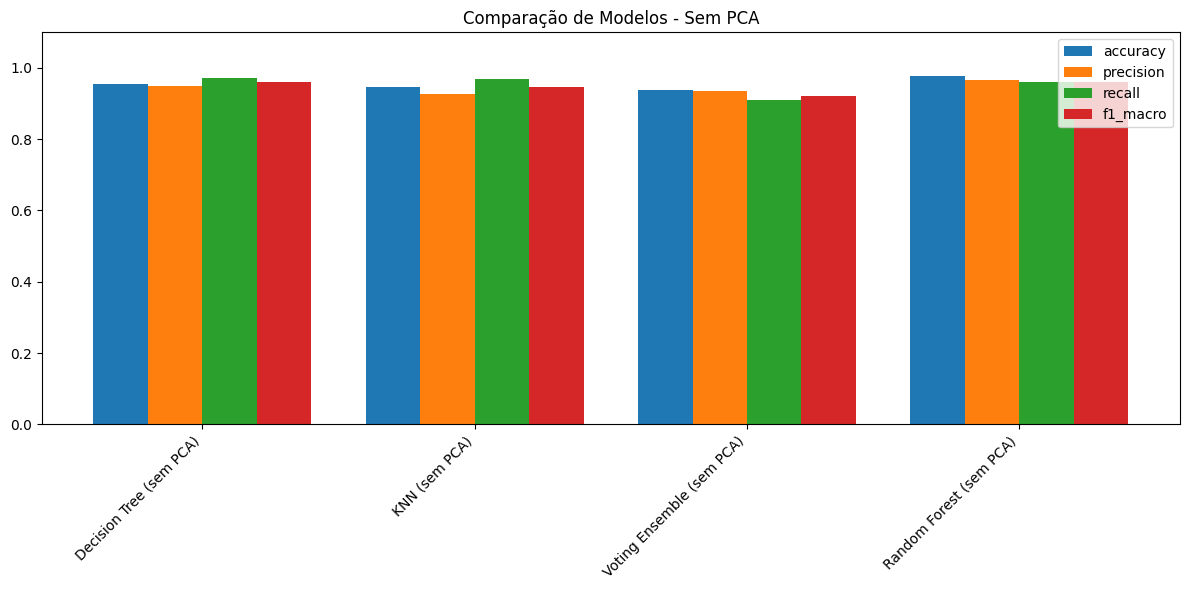

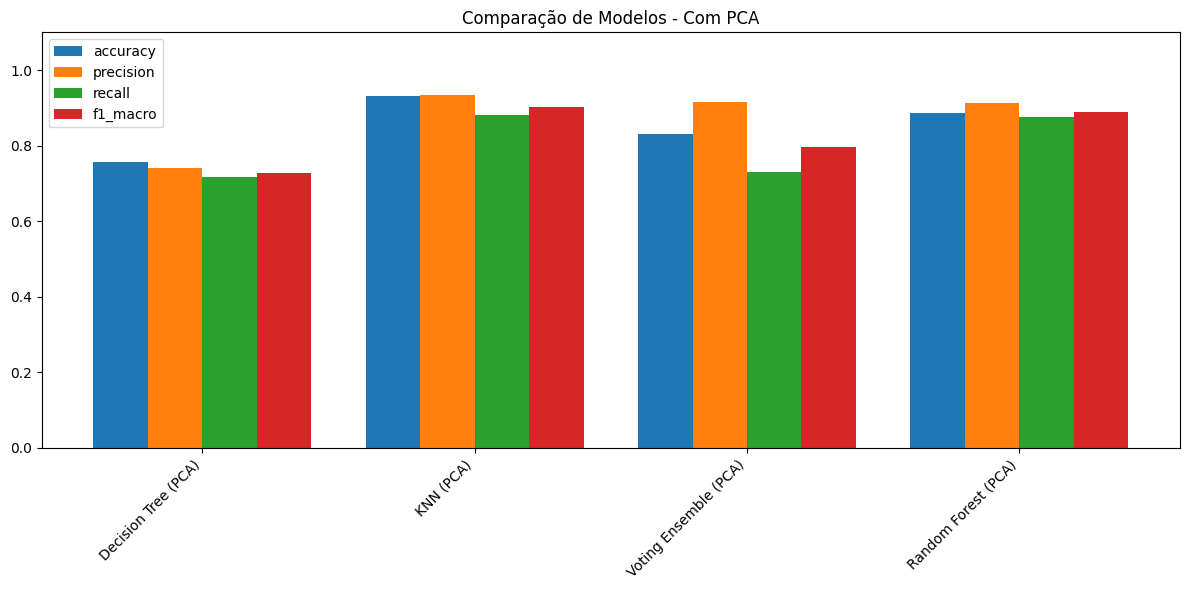

In [21]:
import numpy as np
import matplotlib.pyplot as plt

df_resultados = pd.DataFrame(resultados).set_index("modelo")
print(df_resultados)

metricas = ["accuracy", "precision", "recall", "f1_macro"]
width = 0.2

# SEM PCA
modelos_sem_pca = [m for m in df_resultados.index if "sem PCA" in m]
df_sem_pca = df_resultados.loc[modelos_sem_pca]
x = np.arange(len(df_sem_pca))

fig, ax = plt.subplots(figsize=(12, 6))
for i, metrica in enumerate(metricas):
    ax.bar(x + i * width, df_sem_pca[metrica], width, label=metrica)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_sem_pca.index, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("Comparação de Modelos - Sem PCA")
ax.legend()
plt.tight_layout()
plt.show()

# COM PCA
modelos_com_pca = [m for m in df_resultados.index if "sem PCA" not in m]
df_com_pca = df_resultados.loc[modelos_com_pca]
x = np.arange(len(df_com_pca))

fig, ax = plt.subplots(figsize=(12, 6))
for i, metrica in enumerate(metricas):
    ax.bar(x + i * width, df_com_pca[metrica], width, label=metrica)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_com_pca.index, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("Comparação de Modelos - Com PCA")
ax.legend()
plt.tight_layout()
plt.show()